# Univariate and Bivariate Analysis of Application (loan) Data
- table - application_train.csv
---

__Loan info__:
- `SK_ID_CURR` - ID of loan in our sample
- `TARGET` - Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)
- `NAME_CONTRACT_TYPE` - Identification if loan is cash or revolving
- `AMT_CREDIT` - Credit amount of the loan
- `AMT_ANNUITY` - Loan annuity
- `AMT_GOODS_PRICE` - For consumer loans it is the price of the goods for which the loan is given

## 0. Libraries and Data

In [59]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_quantitative_vs_binary
)

In [60]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. SK_ID_CURR
This is ID of loand in our sample. It won't be used in modeling phase, it may be helpful in joining tables and identifying duplicate observationst though.

In [61]:
if app_df['SK_ID_CURR'].nunique() == app_df.shape[0]:
    print("There aren't any duplicate observations")
else:
    print("There are some duplicate observations")

There aren't any duplicate observations


## 2. Target

This is our dependent variable.

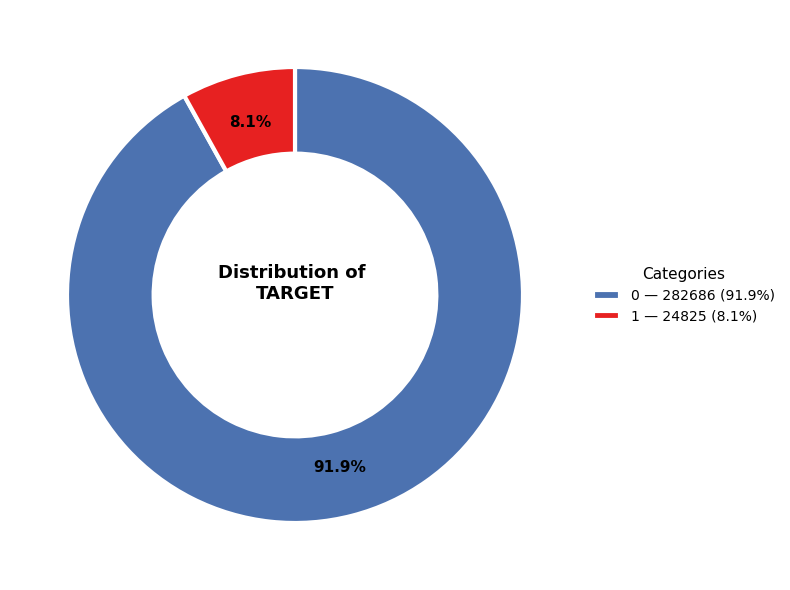

In [62]:
plot_binary_distribution(df=app_df, binary_var='TARGET')

`TARGET` is dominated by category `0` (`non-default`), which has to be accounted for in the modeling phase. <br> Moreover there are no `NAN` values for our dependent variable.

## 4. NAME_CONTRACT_TYPE

Identification if loan is cash or revolving

In [63]:
app_df['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

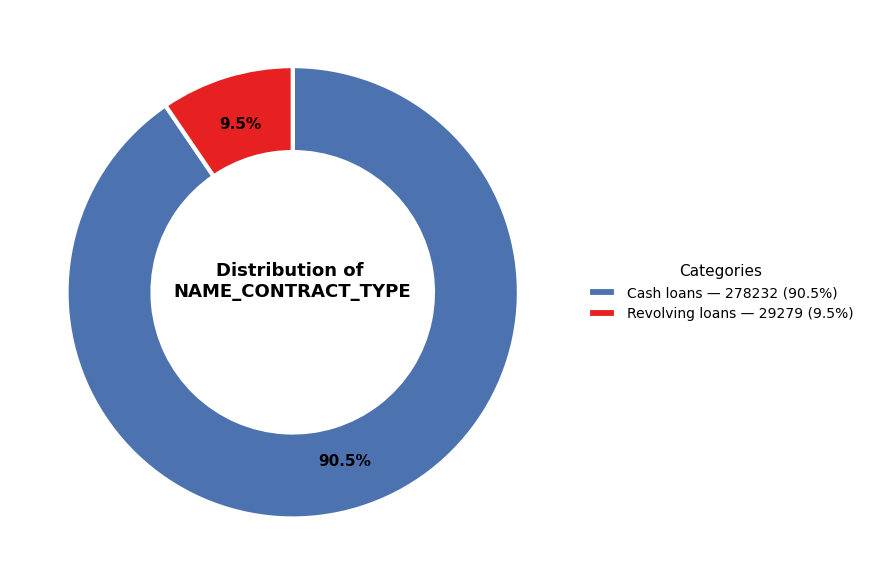

In [64]:
plot_binary_distribution(df=app_df, binary_var='NAME_CONTRACT_TYPE')

`NAME_CONTRACT_TYPE` is dominated by `Cash loans` - 90.5% obs belong to this category. There are no missing values.

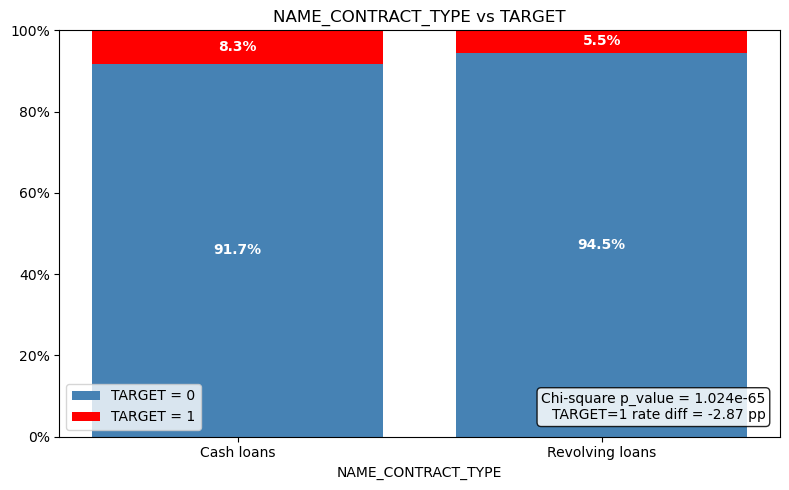

In [65]:
plot_binary_vs_binary(df=app_df, binary_var='NAME_CONTRACT_TYPE', target_var='TARGET')

There is small diference in `TARGET` shares for different `NAME_CATEGORY_TYPE` classes but probably it won't be crucial preditctor.

## 5. AMT_CREDIT

In [66]:
app_df['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

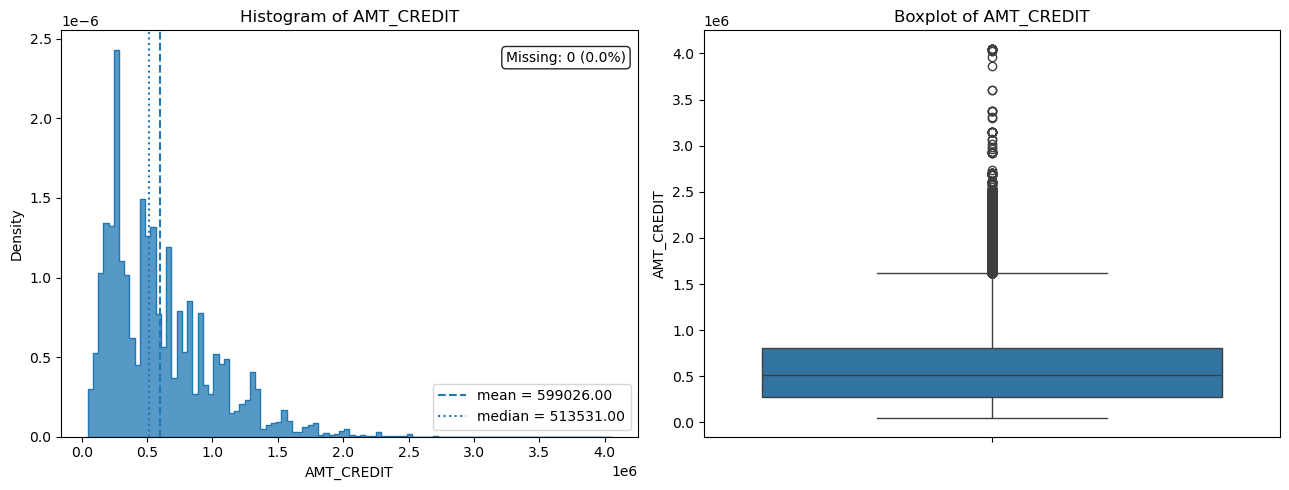

In [67]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_CREDIT', hist_bins=100)

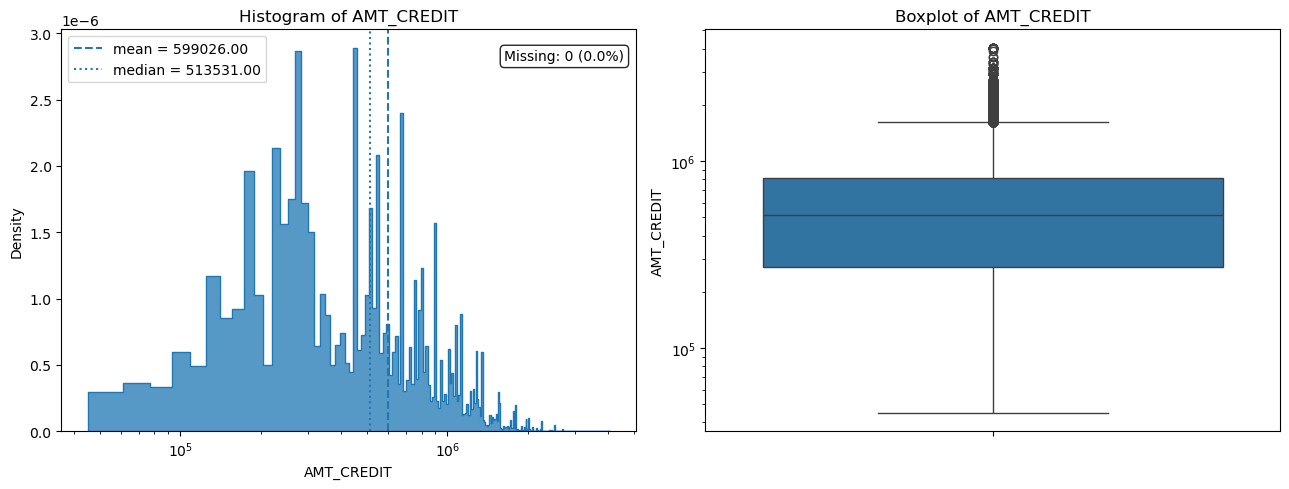

In [68]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_CREDIT', log_scale=True)

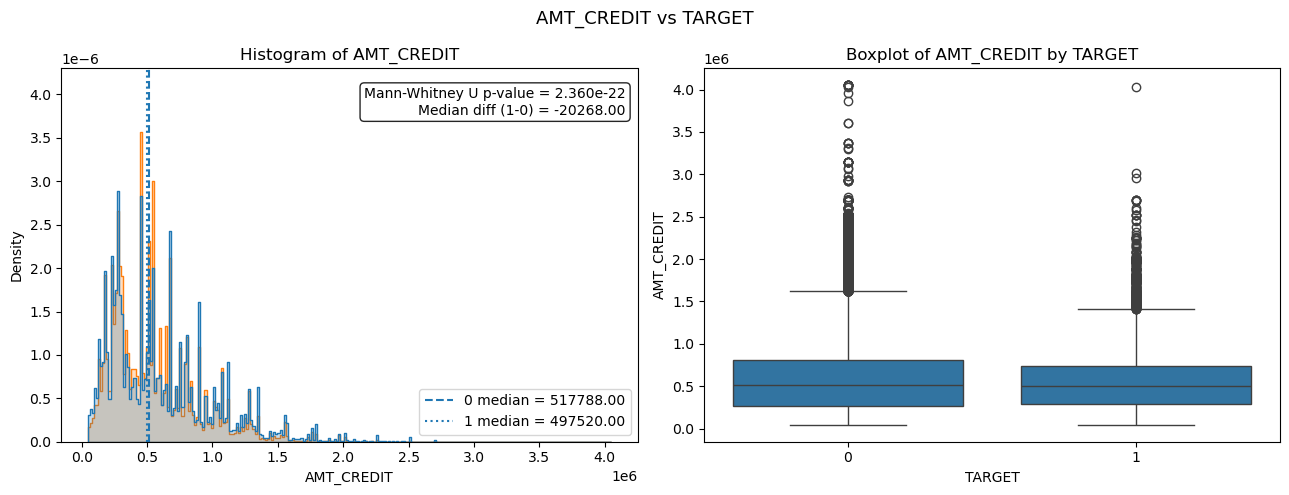

In [69]:
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_CREDIT', binary_var='TARGET')

Surprisingly loans which defaulted had lower `AMT_CREDIT`, which tells us that probably more risky customers where given less credit amount. <br>
The difference is statistically significant but quite small in temrs of value.

## 6. AMT_ANNUITY 
Loan annuity

In [70]:
app_df['AMT_ANNUITY'].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

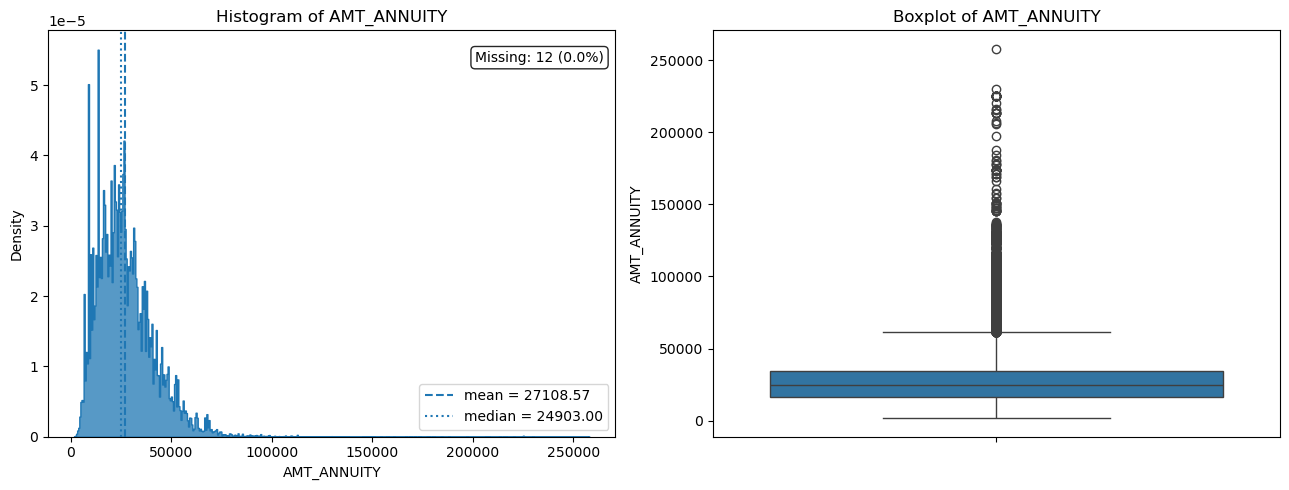

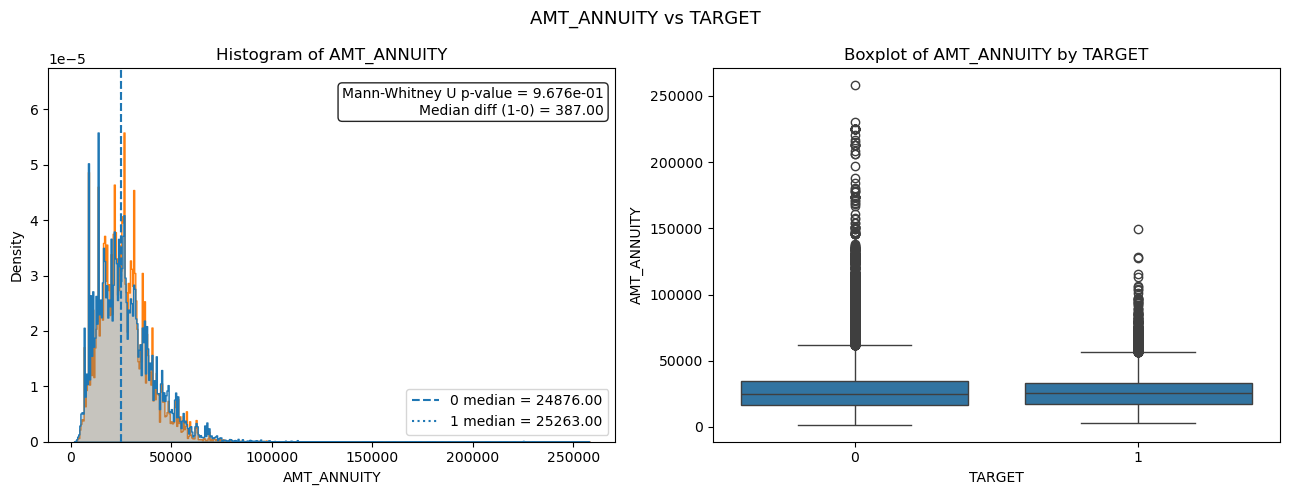

In [71]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_ANNUITY')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_ANNUITY', binary_var='TARGET')

The difference of loan annuity between values of `TARGET` is not statistically significant, so `AMT_ANNUITY` probably won't be a useful predictor.

## 7. AMT_GOODS_PRICE

In [72]:
app_df['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

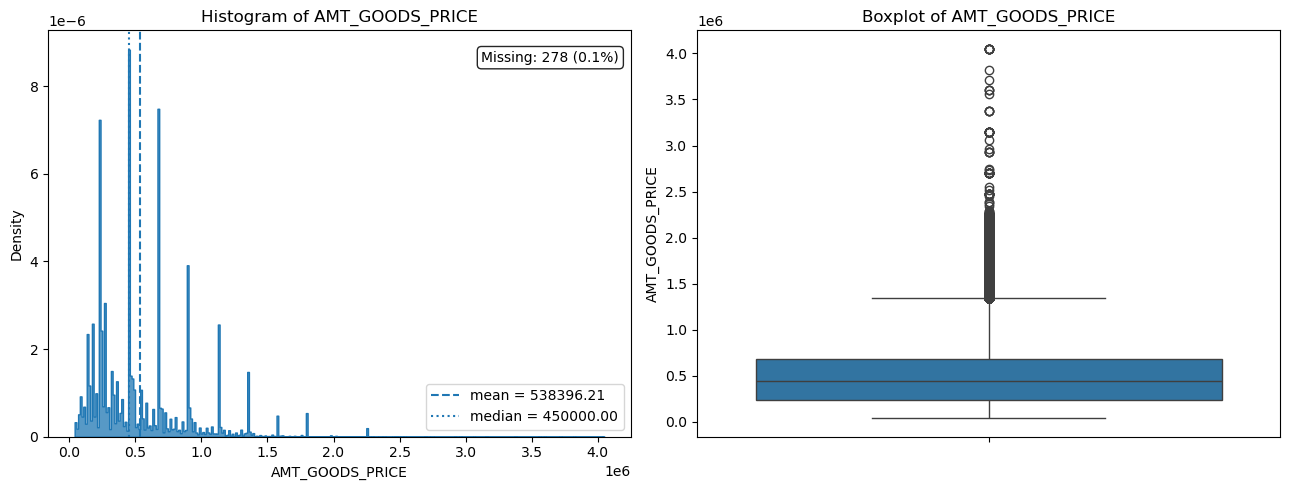

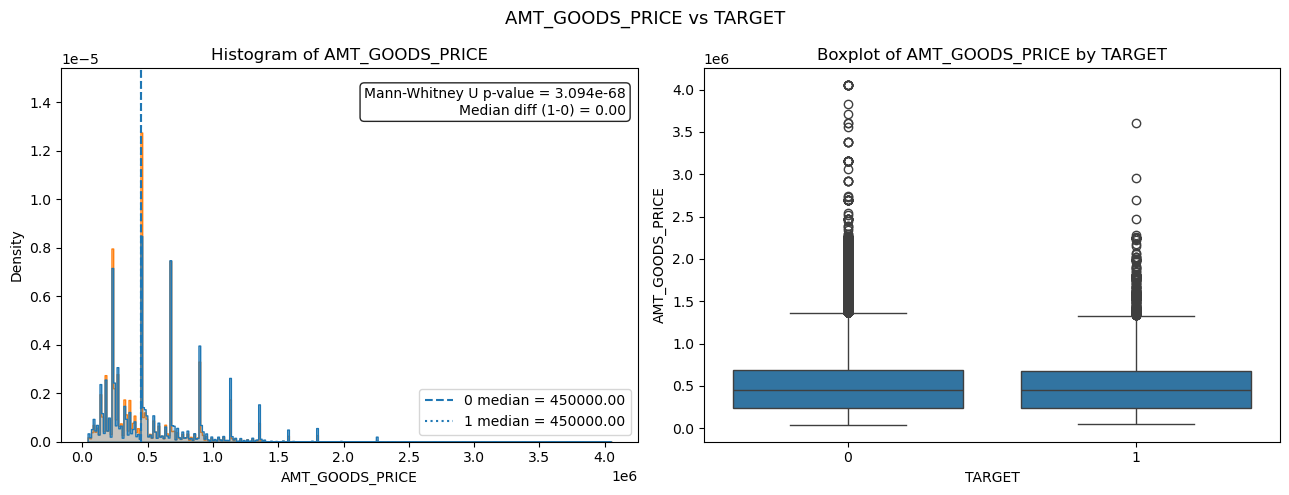

In [73]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_GOODS_PRICE')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_GOODS_PRICE', binary_var='TARGET')

The difference in ditribution of `AMT_GOODS_PRICE` is not statistically significant (medians are equal).

## 8. Loan Info Summary
Variables that can be used as preditcotrs:
- NAME_CONTRACT_TYPE
- AMT_CREDIT
